In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
from figures_setup import *
from utils import set_color_code
import palantir

# SG treatment of liver metastasis (time course)

## Getting data from arrayExpress: E-MTAB-16849

In [15]:
# Download data from arrayExpress and reassemble anndata object 
from utils_arrayExpress import get_public_study_adata, list_accession_files

accession = "E-MTAB-16849"
download_dir = '../data_arrayExpress'

# # List files for the given accession
# file_list = list_accession_files(accession, download_dir)
# # Show only files ending with palantir.h5ad
# palantir_files = file_list[file_list['path'].str.endswith('palantir.h5ad')]
# palantir_files

## Read palantir dataset

In [16]:
file = os.path.join(download_dir, accession, 'HD4246_SG_0h-48h_palantir.h5ad')
adata = sc.read_h5ad(file)
adata

AnnData object with n_obs × n_vars = 11337 × 27594
    obs: 'sample_id', 'line', 'treatment', 'timepoint', 'replicate', 'library', 'leiden', 'batch', 'palantir_pseudotime', 'palantir_entropy'
    var: 'dispersions', 'dispersions_norm', 'gene_trends_clusters'
    uns: 'DM_EigenValues', 'leiden_colors', 'neighbors', 'palantir_start_state', 'palantir_terminal_states', 'palantir_waypoints', 'sample_id_colors', 'timepoint_colors', 'treatment_colors'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_pca', 'X_umap', 'branch_masks', 'palantir_fate_probabilities'
    varm: 'PCs', 'gene_trends_Term_DM1_max', 'gene_trends_Term_DM2_min'
    layers: 'MAGIC_imputed_data'
    obsp: 'DM_Kernel', 'DM_Similarity', 'connectivities', 'distances'

In [17]:
# Extract terminal states from anndata object
ids = [id for id in adata.uns['palantir_terminal_states']['cell_ids']]
names = [name for name in adata.uns['palantir_terminal_states']['state_names']]
terminal_states = pd.Series(names, index=ids)

In [18]:
branches = list(terminal_states.values)

### Plotting palantir results

In [19]:
# Compute gene trends
gene_trends = palantir.presults.compute_gene_trends(
    adata,
    expression_key="MAGIC_imputed_data",
)

Term_DM1_max
[2026-05-03 10:47:00,287] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (3,148) and rank = 1.0.
[2026-05-03 10:47:00,289] [INFO    ] Using covariance function Matern52(ls=1.0).
[2026-05-03 10:47:01,381] [INFO    ] Sigma interpreted as element-wise standard deviation.
Term_DM2_min
[2026-05-03 10:47:05,131] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (3,118) and rank = 1.0.
[2026-05-03 10:47:05,131] [INFO    ] Using covariance function Matern52(ls=1.0).
[2026-05-03 10:47:05,668] [INFO    ] Sigma interpreted as element-wise standard deviation.


In [20]:
# Extract gene expression along pseudotime
genes = ["TACSTD2", "LGR5"]

df_expr = pd.concat(
    {
        (gene, br): (
            adata.varm[f"gene_trends_{br}"]
            .loc[gene]
            .astype(float)
            .reset_index(drop=True)
        )
        for gene in genes
        for br in branches
    },
    axis=1
)

df_expr.index.name = "pseudotime_bin"

df_expr.head(2)

TACSTD2                      LGR5             
               Term_DM2_min Term_DM1_max Term_DM2_min Term_DM1_max
pseudotime_bin                                                    
0                  2.656494     2.664230     0.097860     0.071987
1                  2.654413     2.660632     0.098086     0.072855

In [21]:
import matplotlib.pyplot as plt

def plot_gene_expression_from_df(df_expr, 
                                 branch_name,
                                 color_trop2='green', 
                                 color_lgr5='red',
                                 linewidth=4,
                                 scale_min_max = False,
                                 figsize=(6, 4.5),
                                 title = None):
    # Extract expression data for both genes from the df_expr dictionary
    tacstd2_expr = df_expr[('TACSTD2', branch_name)]  # Directly use the ndarray
    lgr5_expr = df_expr[('LGR5', branch_name)]  # Directly use the ndarray

    # Scale expression per gene if indicated
    if scale_min_max:
        tac_min, tac_max = np.nanmin(tacstd2_expr), np.nanmax(tacstd2_expr)
        lgr5_min, lgr5_max = np.nanmin(lgr5_expr), np.nanmax(lgr5_expr)

        # avoid division by zero if a gene is constant
        if tac_max > tac_min:
            tacstd2_expr = (tacstd2_expr - tac_min) / (tac_max - tac_min)
        else:
            tacstd2_expr = np.zeros_like(tacstd2_expr, dtype=float)

        if lgr5_max > lgr5_min:
            lgr5_expr = (lgr5_expr - lgr5_min) / (lgr5_max - lgr5_min)
        else:
            lgr5_expr = np.zeros_like(lgr5_expr, dtype=float)
        

    # Create an array for pseudotime (assuming row indices represent pseudotime points)
    pseudotime = range(len(tacstd2_expr))

    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)

    # Plot the expression for TACSTD2 and LGR5
    ax.plot(pseudotime, tacstd2_expr, label='TACSTD2', color=color_trop2, linewidth=linewidth)
    ax.plot(pseudotime, lgr5_expr, label='LGR5', color=color_lgr5, linewidth=linewidth)

    # Add labels and title
    title = "" if title is None else title
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Pseudotime", fontsize=14)
    ax.set_ylabel("Scaled expression", fontsize=14)

    # Add a legend
    ax.legend(title="", frameon=False)

    # Show the plot
    plt.tight_layout()
    plt.show()

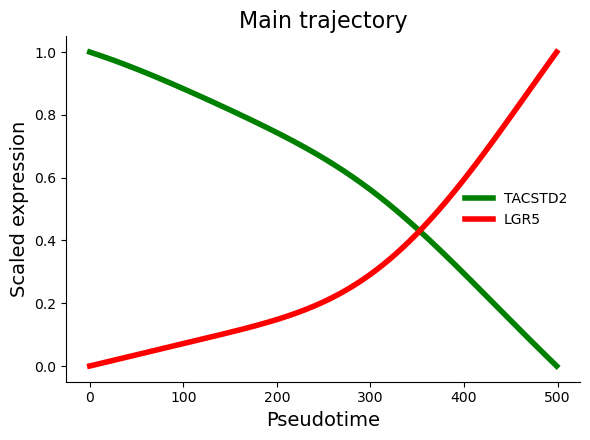

In [22]:
# Get scaled gene expression along pseudotime for main trajectory (Term_DM2_min)
plot_gene_expression_from_df(
    df_expr, 
    branch_name='Term_DM2_min', 
    scale_min_max=True,
    title = "Main trajectory",
)


# Session info

The analysis above has been performed using a micromamba environment with the following package versions:

In [23]:
session_info.show()